# BIPN 162 Final Project Code Notebook Part 1: Replication of Gomari et al.

*Alton Gu, Margaret Jones, Laura Liang*

## Setup
*Are there packages that need to be imported, or datasets that need to be downloaded?*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import seaborn as sns

from sklearn import decomposition
from sklearn.datasets import fetch_openml

from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.layers import BatchNormalization, Dropout, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.losses import mse
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

import tensorflow as tf
tf.random.set_seed(42)

!pip install -q -U keras-tuner # Ultimately not needed because the tuner just would not work
from keras_tuner.tuners import Hyperband, BayesianOptimization
from keras import ops

import IPython

import shutil
import os

import scipy
from scipy import linalg as LA
from scipy.stats import pearsonr

import shap 
from shap.explainers._deep.deep_tf import op_handlers

In [ ]:
# Print versions for reproducibility, Tensorflow especially can be very finnicky
print(f"Keras version: {keras.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Python version: {os.sys.version}")

Keras version: 3.12.0
TensorFlow version: 2.18.0
Pandas version: 2.3.3
Numpy version: 2.2.6
Scipy version: 1.15.2
Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]


## Data Wrangling

### Wrangling of Reference Dataset (Gomari et al.)

In [82]:
# Load the 3 data sets, TwinsUK could not be accessed and is brought up in our report
# Create "Disease" column to keep track of which rows belong to which dataset
df_schizo = pd.read_csv('Schizophrenia_metabolite_data.csv')
df_schizo['Disease'] = 'Schizo'
df_AML = pd.read_csv('AML_metabolite_data.csv')
df_AML['Disease'] = 'AML'
df_diabetes = pd.read_csv('QMDiab_metabolite_data.csv')
df_diabetes['Disease'] = 'Diab'

combined_df = pd.concat([df_schizo, df_AML, df_diabetes], join='inner') # Only shared metabolites are kept in the combined dataset
meta = combined_df[['Disease']]
metabolite_ids = combined_df.columns.tolist()
combined_df_numeric = combined_df.drop(columns=['Disease'])
# combined_df_numeric = combined_df_numeric.drop(combined_df_numeric.index[0], axis=0) # Drop the first row which contains non-numeric values
combined_df_numeric = combined_df_numeric.astype(float) # Convert all values to float

# Confirmation that the combined dataset looks correct
print(combined_df.head())
print(combined_df.shape)

     M33228    M35186    M34214    M34419    M34395    M34389    M35628  \
0 -0.224790  0.367972  0.213836  0.034424 -0.563072 -0.822089 -0.043932   
1 -1.365763 -0.250218 -1.102545  0.106423  0.547012  0.831003 -0.235921   
2  1.361526  1.419471  0.095614  1.458757 -0.131300  0.118827  1.122446   
3 -1.129735 -0.605956 -0.677170 -0.660245  1.392298  1.474983 -0.627671   
4 -0.402553 -0.924436  0.203205  0.649445 -0.653498 -0.428191 -0.667663   

     M33230    M21127    M33955  ...    M37203    M35527    M37190    M37198  \
0  0.765081 -1.229083  0.376804  ...  0.668735 -1.156433  1.380834  1.028611   
1  0.485585 -0.849375  0.587461  ...  0.910195 -0.636947  1.442837 -0.200371   
2  0.505534 -0.656467  1.113982  ... -3.679084 -0.677344 -3.368232  1.096145   
3  0.034415 -1.640713 -0.864807  ...  0.551563 -1.768515  1.591040  1.499522   
4 -0.650306 -0.145957 -0.191565  ...  1.548937  1.241594  0.203979  2.095742   

     M38178    M39379    M38768    M37506    M37097  Disease  
0 -0.

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
# Stratified split to maintain balance in disease status in train and test sets, 80-20 split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# The metabolic expression values become the input data, while the disease labels become the output data.
for train_index, test_index in split.split(combined_df_numeric, meta['Disease']):
    input_train, input_test = combined_df_numeric.iloc[train_index], combined_df_numeric.iloc[test_index]
    result_train, result_test = meta['Disease'].iloc[train_index], meta['Disease'].iloc[test_index]

print(f"Training set size: {len(input_train)}")
print(f"Testing set size: {len(input_test)}")

# Delete the original dataframes to free up memory, we will only be working with the split datasets from now on
del combined_df, combined_df_numeric, df_schizo, df_AML, df_diabetes

Training set size: 515
Testing set size: 129


In [ ]:
# Load the metabolic metadata for later use in interpreting the latent space
metadata_df = pd.read_csv('metabolite_annotations.csv')
metadata_lookup = metadata_df.set_index('COMP_IDstr')

# Confirmation of VAE Pipeline (Gomari et al.)

The parameter optimization and VAE code are directly copied from the Github attached to the paper. Minor tweaks were made to ensure that the code ran smoothly AND to cut down on runtime (in the interest of this project). The first line of the cell will clearly indicate if the code is derived from the paper, and code was altered for reasons other than to simply make it work will be clearly noted.

Github link: https://github.com/krumsieklab/mtVAE

### Parameter Optimization

In [ ]:
# CODE FROM GOMARI ET AL.

# Data & model configuration
batch_size = 32
no_epochs = 1000 #lets keep it shorter for now haha
latent_dim = 18

original_dim = input_train.shape[1]
input_shape = (original_dim,)
# recommended to do this here: https://www.tensorflow.org/tutorials/keras/keras_tuner
class ClearTrainingOutput(tf.keras.callbacks.Callback):
    def on_train_end(*args, **kwargs):
     IPython.display.clear_output(wait = True)
        
        
def model_builder(hp):
    # # =================
    # # Encoder
    # # =================

    # Definition
    i       = Input(shape=input_shape, name='encoder_input')
    
    x       = Dense(hp.Int('encoder_units',
                           min_value=30,
                           max_value=150, # *** min and max were changed to fit with the different dimensions of our data.
                           step=10))(i)
    x       = LeakyReLU()(x)
   
    
    mu      = Dense(latent_dim, name='latent_mu')(x)
    sigma   = Dense(latent_dim, name='latent_sigma')(x)

    # Define sampling with reparameterization trick
    def sample_z(args):
        mu, sigma = args
        batch     = ops.shape(mu)[0]
        dim       = ops.shape(mu)[1]
        eps       = K.random.normal(shape=(batch, dim))
        return mu + ops.exp(sigma / 2) * eps

    # Use reparameterization trick to ....??
    z       = Lambda(sample_z, output_shape=(latent_dim, ), name='z')([mu, sigma])

    # Instantiate encoder
    encoder = Model(i, [mu, sigma, z], name='encoder')
    
    # =================
    # Decoder
    # =================

    # Definition
    d_i   = Input(shape=(latent_dim, ), name='decoder_input')
    
    x     = Dense(hp.Int('decoder_units',
                           min_value=30,
                           max_value=150, # *** min and max were changed to fit with the different dimensions of our data.
                           step=10))(d_i)
    x     = LeakyReLU()(x)
        
    o     = Dense(original_dim)(x)

    # Instantiate decoder
    decoder = Model(d_i, o, name='decoder')
    
    # =================
    # VAE as a whole
    # =================
    beta = hp.Float('kl_beta', min_value=1e-4, max_value=1e-2, sampling='LOG', default=1e-3)
    # Define loss
    def kl_reconstruction_loss(true, pred):
      # Reconstruction loss
        reconstruction_loss = ops.mean(ops.square(true - pred), axis=-1)
        reconstruction_loss *= original_dim

        # 2. KL divergence loss 
        # REPLACE tf.exp or K.exp with ops.exp
        # REPLACE K.square with ops.square
        kl_loss = 1 + sigma - ops.square(mu) - ops.exp(sigma)
        kl_loss = ops.sum(kl_loss, axis=-1)
        kl_loss *= -0.5
        
        weighted_kl = kl_loss * beta

        return ops.mean(reconstruction_loss + weighted_kl)

    # Instantiate VAE
    vae_outputs = decoder(encoder(i)[2])
    vae         = Model(i, vae_outputs, name='vae')


    # Define optimizer
    optimizer = Adam(hp.Float(
        'learning_rate',
        min_value=1e-4,
        max_value=1e-2,
        sampling='LOG',
        default=1e-3
    ))

    
    # Use a basic string for the optimizer and loss to avoid 
    # complex objects that trigger the 'experimental' flags
    vae.compile(
        optimizer='adam', 
        loss='mse',
        metrics=['mse']
    )
    
    # Manually set this to True to bypass the 'must call compile' check
    vae.compiled = True 
    
    return vae
    
# Set tuner parameters
tuner = Hyperband(
    model_builder,
    objective='mse',
    factor=2,
    # *** Decreasing max_epochs in the interest of time
    max_epochs=50,
    directory='hyperband_optimization',
    project_name='gomari_vae',
    overwrite=True)
tuner.search_space_summary()
# Run Tuner
# Runtime on MacBook Pro 2017: 01h 15m

Search space summary
Default search space size: 4
encoder_units (Int)
{'default': None, 'conditions': [], 'min_value': 30, 'max_value': 150, 'step': 10, 'sampling': 'linear'}
decoder_units (Int)
{'default': None, 'conditions': [], 'min_value': 30, 'max_value': 150, 'step': 10, 'sampling': 'linear'}
kl_beta (Float)
{'default': 0.001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
learning_rate (Float)
{'default': 0.001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


In [ ]:
# Convert to numpy array and float32 just to be extra sure that the data will be compatible.

X_train_numeric = input_train.astype('float32').values
X_test_numeric = input_test.astype('float32').values
X_train_pure = np.array(input_train.values, dtype='float32')
X_test_pure  = np.array(input_test.values, dtype='float32')

print(X_train_pure.shape)
print(X_test_pure.shape)
print(X_train_pure)

(515, 162)
(129, 162)
[[-0.94654447  0.14561985  0.33450758 ...  0.49959856 -2.010629
   0.17999202]
 [-2.06575    -0.7213865   0.18113396 ... -1.2235255   1.8960326
   0.6417992 ]
 [ 0.8672581   0.20096202  1.0952833  ...  0.03965542  1.984286
   0.13784967]
 ...
 [-0.53451216 -0.08454747  1.4435806  ...  2.2608037   0.27387094
  -0.27469832]
 [ 0.62475175  1.4978093   1.4475821  ...  0.28384814  1.9139537
   1.1417782 ]
 [-0.23292921 -1.9058897  -2.1310682  ... -0.37088364  0.20030953
  -0.3161781 ]]


We simply could not get the tuner even after debugging for ages, so we ultimately did not continue with it in the interest of time for this project. The code is still included below for reference, and would provide the best dimensions for the intermediate layers, learning rate, and Kullback-Leibler divergence when provided with input dimensions, latent dimensions, and batch size.

The VAE that we used ended up using mostly the same parameters as the ideal ones listed in Gomari et al., with the small tweak of the intermediate dimension being lower to account for our smaller data set.

In [ ]:
# CODE FROM GOMARI ET AL.
tuner.search(
    x=X_train_pure, 
    y=X_train_pure, # Target is the INPUT
    validation_data=(X_test_pure, X_test_pure),
    epochs=10
)
# Print out best tuned parameters
tuner.results_summary(num_trials = 2)
tuner.get_best_models()[0].summary()
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]

print(best_hps.get('encoder_units'))
print(best_hps.get('decoder_units'))
print(best_hps.get('learning_rate'))
print(best_hps.get('kl_beta'))


In [ ]:
# This would have cleaned the many files that the tuner creates.
folder_to_clean = 'hyperband_optimization'

if os.path.exists(folder_to_clean):
    shutil.rmtree(folder_to_clean)

### Gomari et al.'s Code for PCA and VAE

This code sets the template model for PCA, kPCA (which we don't end up using), and VAE. Except for changes made to make the code work, it is otherwise left untouched.

In [94]:
# CODE FROM GOMARI ET AL.

def PCA(data):
    
    data_raw = data
    #centering the data
    data -= np.mean(data, axis = 0)  

    cov = np.cov(data, rowvar = False)

    evals , evecs = LA.eigh(cov)

    # sort the eigenvalues (and eigenvectors accordingly) descending
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    
    # sort the eigenvectors
    S = evecs[:,idx]
    
    A = np.dot(data, S) 
    
    np.testing.assert_array_almost_equal(np.matmul(A, LA.inv(S)), data_raw)
    
    # calculate loadings of each PCA component
    loadings = S * np.sqrt(evals)
    
    return([A, S, loadings])

    

class PCA_model:
    
    def __init__(self, reference_data, k):
        self.reference_data = reference_data
        self.k = k
        self.A, self.S, self.loadings = PCA(self.reference_data)
    
    def encode(self, target_data):

        # PCA encode target_data
        A2 = np.dot(target_data, self.S) 

        return(A2[:,:self.k])
    
    def reconstruct(self, target_data):

        # PCA encode target_data
        A2 = np.dot(target_data, self.S) 
        
        # reconstruct target_data based on learned S
        Xrec = np.matmul(A2[:, :self.k], LA.inv(self.S)[:self.k, ]) # Note: S.T == LA.inv(S) in this case, since eigen-vector matrix

        return(Xrec)
    
    def get_loadings(self):
        
        return(self.loadings[:,:self.k])



def KPCA(data, k, kernel, alpha, gamma, coef0, degree):

    data_raw = data
    
    #centering the data
    data -= np.mean(data, axis = 0)  

    kPCA = KernelPCA(n_components = k, kernel=kernel, alpha=alpha, gamma=gamma, coef0=coef0, degree=degree, fit_inverse_transform=True)

    kPCA.fit(data)
    
    return kPCA


class KPCA_model:
    
    def __init__(self, reference_data, k, kernel, alpha, gamma, coef0, degree):
        self.reference_data = reference_data
        self.k = k
        self.kernel= kernel
        self.alpha = alpha
        self.gamma = gamma
        self.coef0 = coef0 
        self.degree = degree
        self.model = KPCA(self.reference_data, self.k, self.kernel, self.alpha, self.gamma, self.coef0, self.degree)
    
    def encode(self, target_data):

        # KPCA transform target_data
        A2 = self.model.transform(target_data) 

        return(A2)
    
    def reconstruct(self, target_data):

        encoded = self.encode(target_data)

        return self.model.inverse_transform(encoded)

class Sampling(keras.layers.Layer): # *** This class was added to fix some issues with the original code
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Creating a seed generator handles the "seed must have shape [2]" error
        self.seed_generator = keras.random.SeedGenerator(42)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        
        # Use the seed_generator to keep TensorFlow happy
        epsilon = keras.random.normal(
            shape=(batch, dim), 
            seed=self.seed_generator
        )
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon

class mtVAE():

    def __init__(self,
                input_shape,
                intermediate_dim,
                latent_dim,
                kl_beta=1e-2,
                learning_rate=1e-3):
        
        self.input_shape = input_shape
        self.intermediate_dim = intermediate_dim
        self.latent_dim = latent_dim
        self.kl_beta = kl_beta
        self.learning_rate = learning_rate
        
        # # =================
        # # Encoder
        # # =================

        # Definition
        self.input   = Input(shape=(self.input_shape,), name='encoder_input')
        self.x       = Dense(self.intermediate_dim)(self.input)
        self.x       = LeakyReLU()(self.x)


        self.mu      = Dense(self.latent_dim, name='latent_mu')(self.x)
        self.sigma   = Dense(self.latent_dim, name='latent_sigma')(self.x)
       
        # Define sampling with reparameterization trick
       
        self.z = Sampling()([self.mu, self.sigma])
        # Instantiate encoder
        self.encoder = Model(self.input, [self.mu, self.sigma, self.z], name='encoder')

        # =================
        # Decoder
        # =================

        # Definition
        self.decoder_input   = Input(shape=(self.latent_dim, ), name='decoder_input')
        self.x     = Dense(self.intermediate_dim)(self.decoder_input)
        self.x     = LeakyReLU()(self.x)

        self.output  = Dense(self.input_shape)(self.x)

        # Instantiate decoder
        self.decoder = Model(self.decoder_input, self.output, name='decoder')

        # =================
        # VAE as a whole
        # =================

        # Instantiate VAE
        self.vae_outputs = self.decoder(self.encoder(self.input)[2])
        self.vae         = Model(self.input, self.vae_outputs, name='vae')

        def compute_kl(args):
            mu, sigma = args
            kl_loss = -0.5 * ops.sum(1 + sigma - ops.square(mu) - ops.exp(sigma), axis=-1)
            return ops.mean(kl_loss)

        kl_val = keras.layers.Lambda(
        lambda x: x, # Just pass data through
        activity_regularizer=lambda x: compute_kl([self.mu, self.sigma]) * self.kl_beta,
        name='kl_loss_layer'
        )([self.mu, self.sigma])

        # Define optimizer
        self.optimizer = Adam(learning_rate=self.learning_rate)
        
        # Define loss
        def kl_reconstruction_loss(true, pred):
            # Reconstruction loss
            reconstruction_loss = mse(true, pred)
            reconstruction_loss *= self.input_shape

            # KL divergence loss
            kl_loss = 1 + self.sigma - ops.square(self.mu) - ops.exp(self.sigma)
            kl_loss = ops.sum(kl_loss, axis=-1)
            kl_loss *= -0.5

            # Total loss = 50% rec + 50% KL divergence loss
            return ops.mean(reconstruction_loss + self.kl_beta*kl_loss)

        # Compile VAE
        self.vae.compile(optimizer=self.optimizer, loss='mse')
    
    
    def train(self, train_data, val_data, n_epochs, batch_size, verbosity=0):
        
        self.vae.fit(train_data, train_data,
                     epochs = n_epochs, 
                     batch_size = batch_size, 
                     validation_data = (val_data, val_data),
                     verbose = verbosity)
    
    def encode(self, data):
        return self.encoder.predict(data)[2]
    
    def encode_mu(self, data):
        return self.encoder.predict(data)[0]
    
    def decode(self, data):
        return self.decoder.predict(data)
    
    def reconstruct(self, data):
        return self.decode(self.encode(data))
    
    def save_model(self, save_folder):
        
        vae_path     = save_folder + 'VAE.h5'
        encoder_path = save_folder + 'VAE_encoder.h5'
        decoder_path = save_folder + 'VAE_decoder.h5'
        
        self.vae.save(vae_path)
        self.encoder.save(encoder_path)
        self.decoder.save(decoder_path)
        
    
    def load_vae(self, save_path):

        # The two functions below have to be redefined for the loading
        # of the model. They cannot be methods of the mtVAE class for
        # some reason.
        # https://github.com/keras-team/keras/issues/13992
        
        # Define sampling with reparameterization trick
        def sample_z(args):
            mu, sigma = args
            batch     = ops.shape(mu)[0]
            dim       = ops.shape(mu)[1]
            eps       = keras.random.normal(shape=[batch, dim])
            return mu + ops.exp(sigma / 2) * eps
        
                # Define loss
        def kl_reconstruction_loss(true, pred):
            # Reconstruction loss
            reconstruction_loss = mse(true, pred)
            reconstruction_loss *= self.input_shape

            # KL divergence loss
            kl_loss = 1 + self.sigma - ops.square(self.mu) - ops.exp(self.sigma)
            kl_loss = ops.sum(kl_loss, axis=-1)
            kl_loss *= -0.5

            # Total loss = 50% rec + 50% KL divergence loss
            return K.mean(reconstruction_loss + self.kl_beta*kl_loss)
        
        keras.losses.kl_reconstruction_loss = kl_reconstruction_loss
        self.vae = keras.models.load_model(save_path)
        self.vae.compile(optimizer=self.optimizer, 
                         custom_objects={'sample_z': sample_z}, 
                         loss=kl_reconstruction_loss, 
                         metrics = ['mse'])
        
    def load_encoder(self, save_path):
        self.encoder = keras.models.load_model(save_path)
        
    def load_decoder(self, save_path):
        self.decoder = keras.models.load_model(save_path)

### Metric Measurements

Most importantly, this code gets the correlation matrix mean squared error (CM-MSE), which is a measure of how well the model preserves internal relationships (e.g. interactions between metabolites). This code is completely untouched.

In [95]:
# CODE FROM GOMARI ET AL.

def get_correlations(x1, x2, rowwise = True):

    if rowwise:
        cors = [pearsonr(x1[idx,], x2[idx,])[0] for idx in range(x1.shape[0])]
    else:
        cors = [pearsonr(x1[:,idx], x2[:,idx])[0] for idx in range(x1.shape[1])]

    return(cors)


def get_mse(A, B, rowwise = True):

    if rowwise:
        ax = 0
        mse = ((A - B)**2).mean(axis=ax)
    else:
        ax = 1
        mse = ((A - B)**2).mean(axis=ax)

    return(mse)


def get_mae(A, B, rowwise = True):

    if rowwise:
        ax = 0
        mae = np.abs(A - B).mean(axis=ax)
    else:
        ax = 1
        mae = np.abs(A - B).mean(axis=ax)

    return(mae)
        

def matrix_cor(x, y):

    return np.corrcoef(np.corrcoef(x, rowvar = False).flatten(), np.corrcoef(y, rowvar = False).flatten())[0,1]


def matrix_mse(x, y):
    
    mses = get_mse(np.corrcoef(x, rowvar = False).flatten(), np.corrcoef(y, rowvar = False).flatten())
    return np.mean(mses)

def matrix_mae(x, y):
    
    maes = get_mae(np.corrcoef(x, rowvar = False).flatten(), np.corrcoef(y, rowvar = False).flatten())
    return np.mean(maes)

### VAE Training

The actual meat of the code, this trains the VAE model set up earlier using our reduced dataset. As mentioned before, only the intermediate dimensions were changed to be lower than the input dimensions (otherwise a pretty arbitrary number though).

In [ ]:
input_dim = X_train_pure.shape[1]
intermediate_dim = 50
latent_dim = 18

kl_beta = 1e-2
learning_rate = 1e-3

batch_size = 32
n_epochs = 1000 # default is 1000

# instantiate model
mtmodel = mtVAE(int(input_dim),
                int(intermediate_dim),
                int(latent_dim),
                float(kl_beta),
                float(learning_rate))

# Verbosity set to 0, which means that no progress bar will be shown.
# If it was shown there would be 1000 lines, which wouldn't look great in our submission.
mtmodel.train(X_train_pure, X_test_pure, n_epochs, batch_size)

### PCA and VAE Comparisons

This code gets the sample-wise and the correlation matrix (what we're interested in) MSEs for PCA and our trained VAE model. The code is completely untouched, and the resulting CM-MSEs will be used in visualization.

In [97]:
input_train_val = X_train_pure
input_test_val  = X_test_pure

# CODE FROM GOMARI ET AL.

######################
# Define PCA model
######################
PCA_model_ = PCA_model(input_train_val, latent_dim)
# Generate TwinsUK dataset reconstructions with VAE and PCA
VAE_train = mtmodel.reconstruct(input_train_val)
VAE_test  = mtmodel.reconstruct(input_test_val)

PCA_train = PCA_model_.reconstruct(input_train_val)
PCA_test  = PCA_model_.reconstruct(input_test_val)
# Calculate sample-wise MSEs
test_mses       = np.mean(get_mse(VAE_test,  input_test_val))
train_mses      = np.mean(get_mse(VAE_train, input_train_val))
test_mses_pca   = np.mean(get_mse(PCA_test,  input_test_val))
train_mses_pca  = np.mean(get_mse(PCA_train, input_train_val))


print('==================== Sample-wise ============================')
print('======================= MSEs ================================')
print('\t \t \t VAE \t \t \t PCA')
print('Input train:\t ',  train_mses, '\t ', train_mses_pca)
print('Input test:\t ',   test_mses,  '\t ', test_mses_pca)
print('')
print('')


# Calculate correlation matrix MSEs (i.e. CM-MSEs)
test_mses  = matrix_mse(VAE_test,  input_test_val)
train_mses = matrix_mse(VAE_train, input_train_val)

test_mses_pca  = matrix_mse(PCA_test,  input_test_val)
train_mses_pca = matrix_mse(PCA_train, input_train_val)

print('================= Correlation Matrix ========================')
print('======================= MSEs ================================')
print('\t \t \t VAE \t \t \t PCA')
print('Input train:\t ',  train_mses, '\t ', train_mses_pca)
print('Input test:\t ',   test_mses, '\t ',  test_mses_pca)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
==================== Sample-wise ============================
======================= MSEs ================================
	 	 	 VAE 	 	 	 PCA
Input train:	  0.44071358 	  0.5890329731384873
Input test:	  0.98471606 	  0.6259892308846319


================= Correlation Matrix ========================
======================= MSEs ================================
	 	 	 VAE 	 	 	 PCA
Input train:	  0.006852787333137158 	  0.020068482963582827
Input test:	  0.023009948457921696 	  0.03320223575895589


# Data Analysis and Visualizations

### CM-MSE Comparisons between PCA and VAE; Training and Test Data (Figure 1)

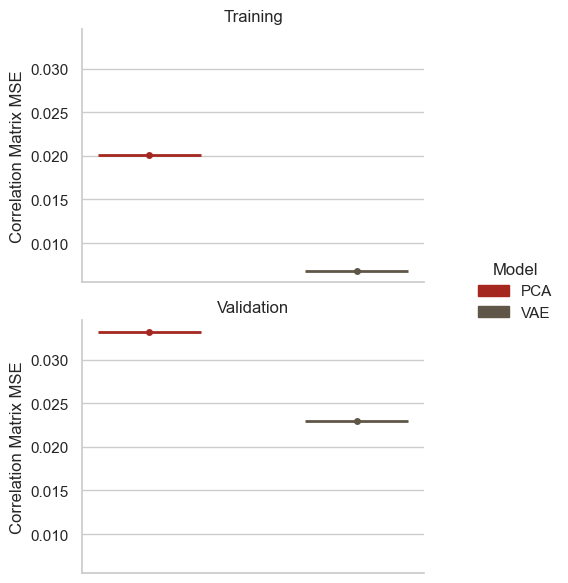

In [98]:
data = pd.DataFrame({
    "dataset": ["Training","Training","Validation","Validation"],
    "model": ["PCA","VAE","PCA","VAE"],
    "value": [
        train_mses_pca, #plug in variable for PCA Training MSE
        train_mses, #plug in variable for VAE Training MSE
        test_mses_pca, #plug in variable for PCA Validation MSE
        test_mses  #plug in variable for VAE Validation MSE
    ]
})

palette = {"PCA": "#A42820", "VAE": "#5F5647"}

sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=data,
    x="model",
    y="value",
    row="dataset",
    hue="model",
    kind="strip",
    height=3,
    aspect=1.5,
    palette=palette,
    legend=False,
)

for ax, (_, subset) in zip(g.axes.flat, data.groupby("dataset")):
    for _, row in subset.iterrows():
        x_pos = 0 if row["model"] == "PCA" else 1
        ax.hlines(
            y=row["value"],
            xmin=x_pos - 0.25,
            xmax=x_pos + 0.25,
            colors=palette[row["model"]],
            linewidth=2
        )

#axis labels
g.set_axis_labels("", "Correlation Matrix MSE")

#remove x-axis tick labels
for ax in g.axes.flat:
    ax.set_xticklabels([])

g.set_titles("{row_name}")

#legend
handles = [Patch(color=color, label=label) for label, color in palette.items()]
g.fig.legend(
    handles=handles,
    title="Model",
    bbox_to_anchor=(1.05, 0.5),
    loc='center left',
    frameon=False
)
g.fig.subplots_adjust(right=0.8)

plt.tight_layout()
plt.show()

### SHAP (Shapley Additive Explanations) Analysis

To find relevant metabolites contributing to the latent dimensions of the model, Gomari et al. uses SAGE analysis instead. SAGE is likely a little more accurate than SHAP, but it also takes exponentially longer. We decided to find a viable alternative to SAGE in the form of SHAP for the sake of time.

In [ ]:
# uses the VAE encoder to predict the latent means (mu) for a given input x, which is necessary for SHAP's KernelExplainer to work with our VAE model.
# SHAP fails to work when .predict is direct used as the input for some reason
def predict_mu(x):
    return mtmodel.encoder.predict(x.astype('float32'), verbose=0)[0]

# Uses kmeans to create 15 centroids, which is required for the explainer to work
# Sample size of 100 from the training data
background_summary = shap.kmeans(X_train_pure[:100], 15)

# DeepExplainer (meant for ML models) would not work, so a more general KernelExplainer is used instead.
explainer = shap.KernelExplainer(predict_mu, background_summary)

# Calculate SHAP values for a small subset
# Based on the explainer and a sample size of 25 from the test data
test_subset = X_test_pure[:25].astype('float32')
shap_values = explainer.shap_values(test_subset)


100%|██████████| 25/25 [00:23<00:00,  1.06it/s]


In [ ]:
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"List length: {len(shap_values)}")
    print(f"Shape of first element: {np.array(shap_values[0]).shape}")
else:
    print(f"Shape of array: {shap_values.shape}")
print(f"Shape of test_subset: {test_subset.shape}")

# shap_values contains 3 numbers (test sample size, # of metabolites, latent dimensions)
# Eventually, we only want to reorder it so that the latent dimensions are first.

Type of shap_values: <class 'numpy.ndarray'>
Shape of array: (25, 162, 18)
Shape of test_subset: (25, 162)


In [ ]:
# Given the following inputs:
#   shap_vals: The SHAP values deterined for a given latent dimension
#   feature_names: The names of the features (metabolites) corresponding to the SHAP values
# Gets the top 10 most important metabolites for a given latent dimension, 
# and returns a summary table with the metabolite name, subpathway, and SHAP importance score.
def get_top_metabolites(shap_vals, feature_names, top_n=10):
    # 1. Calculate the mean absolute SHAP value for each feature
    importance = np.abs(shap_vals).mean(0)
    
    # 2. Get indices of the top features
    top_indices = np.argsort(importance)[-top_n:][::-1]
    
    # 3. Create a list of the top IDs
    top_ids = [feature_names[i] for i in top_indices]
    
    # 4. Pull the metadata
    # We use .reindex to avoid errors if an ID is missing in the metadata
    summary_table = metadata_lookup.reindex(top_ids).copy()
    
    # 5. Add the Importance Score
    summary_table['SHAP_Importance'] = importance[top_indices]
    
    # We chose to look at the subpathway because its more specific.
    columns_to_show = ['BIOCHEMICAL', 'SUB_PATHWAY', 'SHAP_Importance']

    return summary_table[columns_to_show]

In [92]:
# Gets the latent means from the encoder prediction function
latent_means, _, _ = mtmodel.encoder.predict(X_test_pure, verbose=0)
feature_names = [f"LD{i+1}" for i in range(18)]

# Generates a dataframe of latent means with latent dimension # as the column header, used for disease-specific correlations
df_latent = pd.DataFrame(latent_means, columns=feature_names)

# Calculates a correlation matrix for the heatmap
corr_matrix = df_latent.corr()

print(df_latent.head())

         LD1       LD2       LD3        LD4        LD5       LD6       LD7  \
0   1.972290  3.440090  0.357139  13.829187 -11.547165 -5.990035 -0.823602   
1  11.781227 -0.924946  2.790640  -2.645350   8.648170 -5.916312 -5.605791   
2   2.523867 -2.298282 -0.224661  -1.124961  -1.173776 -0.646840  1.440732   
3   1.755776 -3.057898 -5.027156   3.999526   1.496715 -7.534996 -1.352644   
4   2.835508 -0.494351 -2.311646  -5.208317   4.201046 -1.842355  7.782452   

        LD8       LD9      LD10       LD11      LD12      LD13      LD14  \
0  1.584986 -4.689938  5.797301  11.452326 -4.370501 -2.654605 -1.632234   
1  3.170004 -0.123672  8.711466  -1.750923 -1.628560  0.315166 -9.948271   
2  5.275650  1.529036  3.375192   1.527103 -1.496527 -3.595808  1.346559   
3  6.092402  8.177910  1.890124  -6.634209 -4.542178  7.388750  6.750546   
4  4.997894  6.815756 -1.825730   1.133987 -4.134208  2.409261  7.683537   

        LD15      LD16      LD17      LD18  
0   5.128109  5.124055  2.387

### Heatmap of Latent Dimension Correlations and Table of Correlations between Latent Dimensions and Disease (Figure 2)

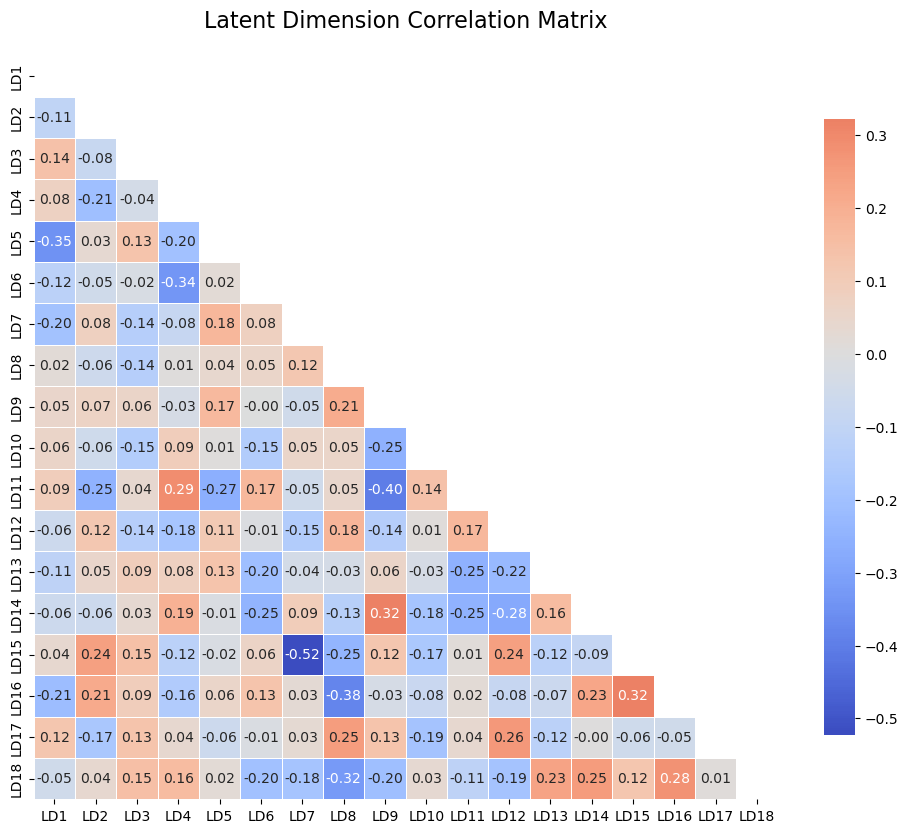

In [ ]:
# Hides the upper triangle of the heatmap to look nicer
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))

# Plotting the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,               # Only shows the bottom half
    cmap='coolwarm',         # Blue for negative, Red for positive
    center=0,                # Ensures white is exactly 0
    annot=True,              # Shows the R-values in the boxes
    fmt=".2f",               # Rounds numbers to 2 decimal places
    linewidths=0.5,          # Adds a small gap between squares
    square=True,             # Makes the cells perfect squares
    cbar_kws={"shrink": .8}  # Makes the colorbar a bit smaller
)

plt.title("Latent Dimension Correlation Matrix", fontsize=16, pad=20)
plt.show()

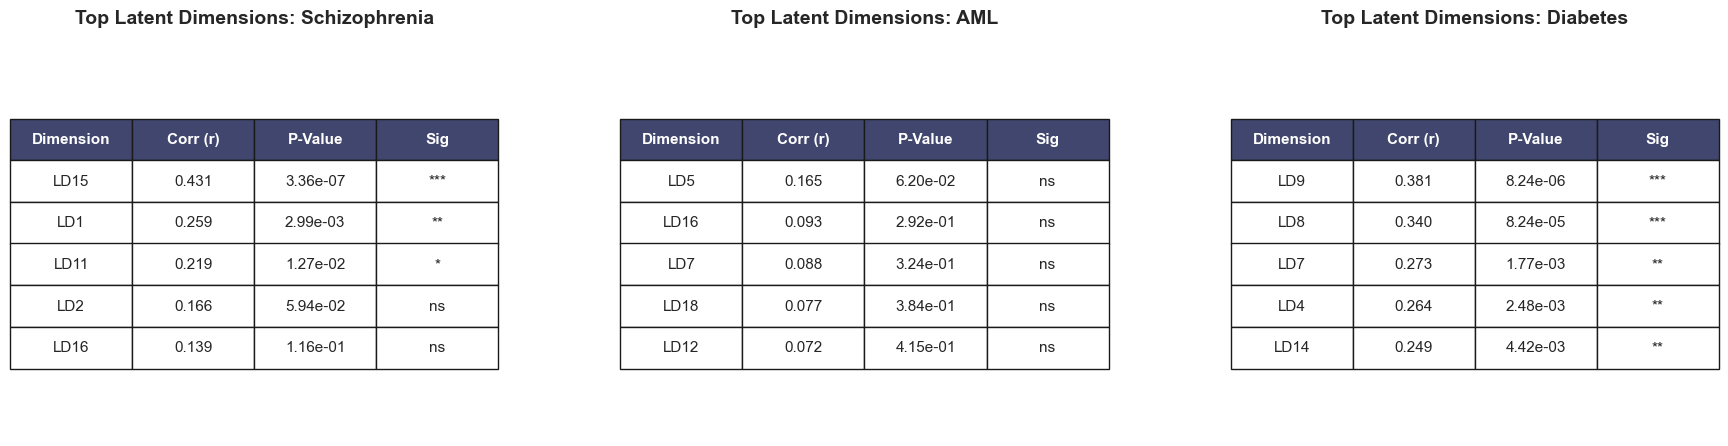

In [86]:
# Ranks latent dimensions by correlation and include p-values for each of the 3 diseases.
def plot_disease_tables(disease_list):
    # Setup the figure for side-by-side tables
    fig, axes = plt.subplots(1, len(disease_list), figsize=(7 * len(disease_list), 5), gridspec_kw={'wspace': 0.5})

    for i, disease_name in enumerate(disease_list):
        # If result_test (disease name) contains given disease, then is_disease = 1, else 0
        if disease_name == "Schizophrenia":
            is_disease = (result_test.values == 'Schizo').astype(int)
        elif disease_name == "AML":
            is_disease = (result_test.values == 'AML').astype(int)
        elif disease_name == "Diabetes":
            is_disease = (result_test.values == 'Diab').astype(int)
        
        # Use Pearson to find r- and p-values for each latent dimension's correlation with the disease status
        data_for_table = []
        for col in feature_names:
            r, p = pearsonr(df_latent[col], is_disease)
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns" # asterisks for significance levels
            data_for_table.append([col, f"{r:.3f}", f"{p:.2e}", sig])
            
        # Sort by correlation, get the top correlation values
        data_for_table.sort(key=lambda x: float(x[1]), reverse=True)
        top_5 = data_for_table[:5]
        
        # Display the table
        ax = axes[i]
        ax.axis('off')
        ax.set_title(f"Top Latent Dimensions: {disease_name}", fontsize=14, weight='bold', pad=20)
        
        table = ax.table(
            cellText=top_5,
            colLabels=['Dimension', 'Corr (r)', 'P-Value', 'Sig'],
            loc='center',
            cellLoc='center'
        )
        
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1.2, 2.5) # Scales width and height (row height is the 2.5)
        
        for (row, col), cell in table.get_celld().items():
            if row == 0:
                cell.set_text_props(weight='bold', color='white')
                cell.set_facecolor('#40466e') # Navy blue header

    plt.show()

plot_disease_tables(["Schizophrenia", "AML", "Diabetes"])

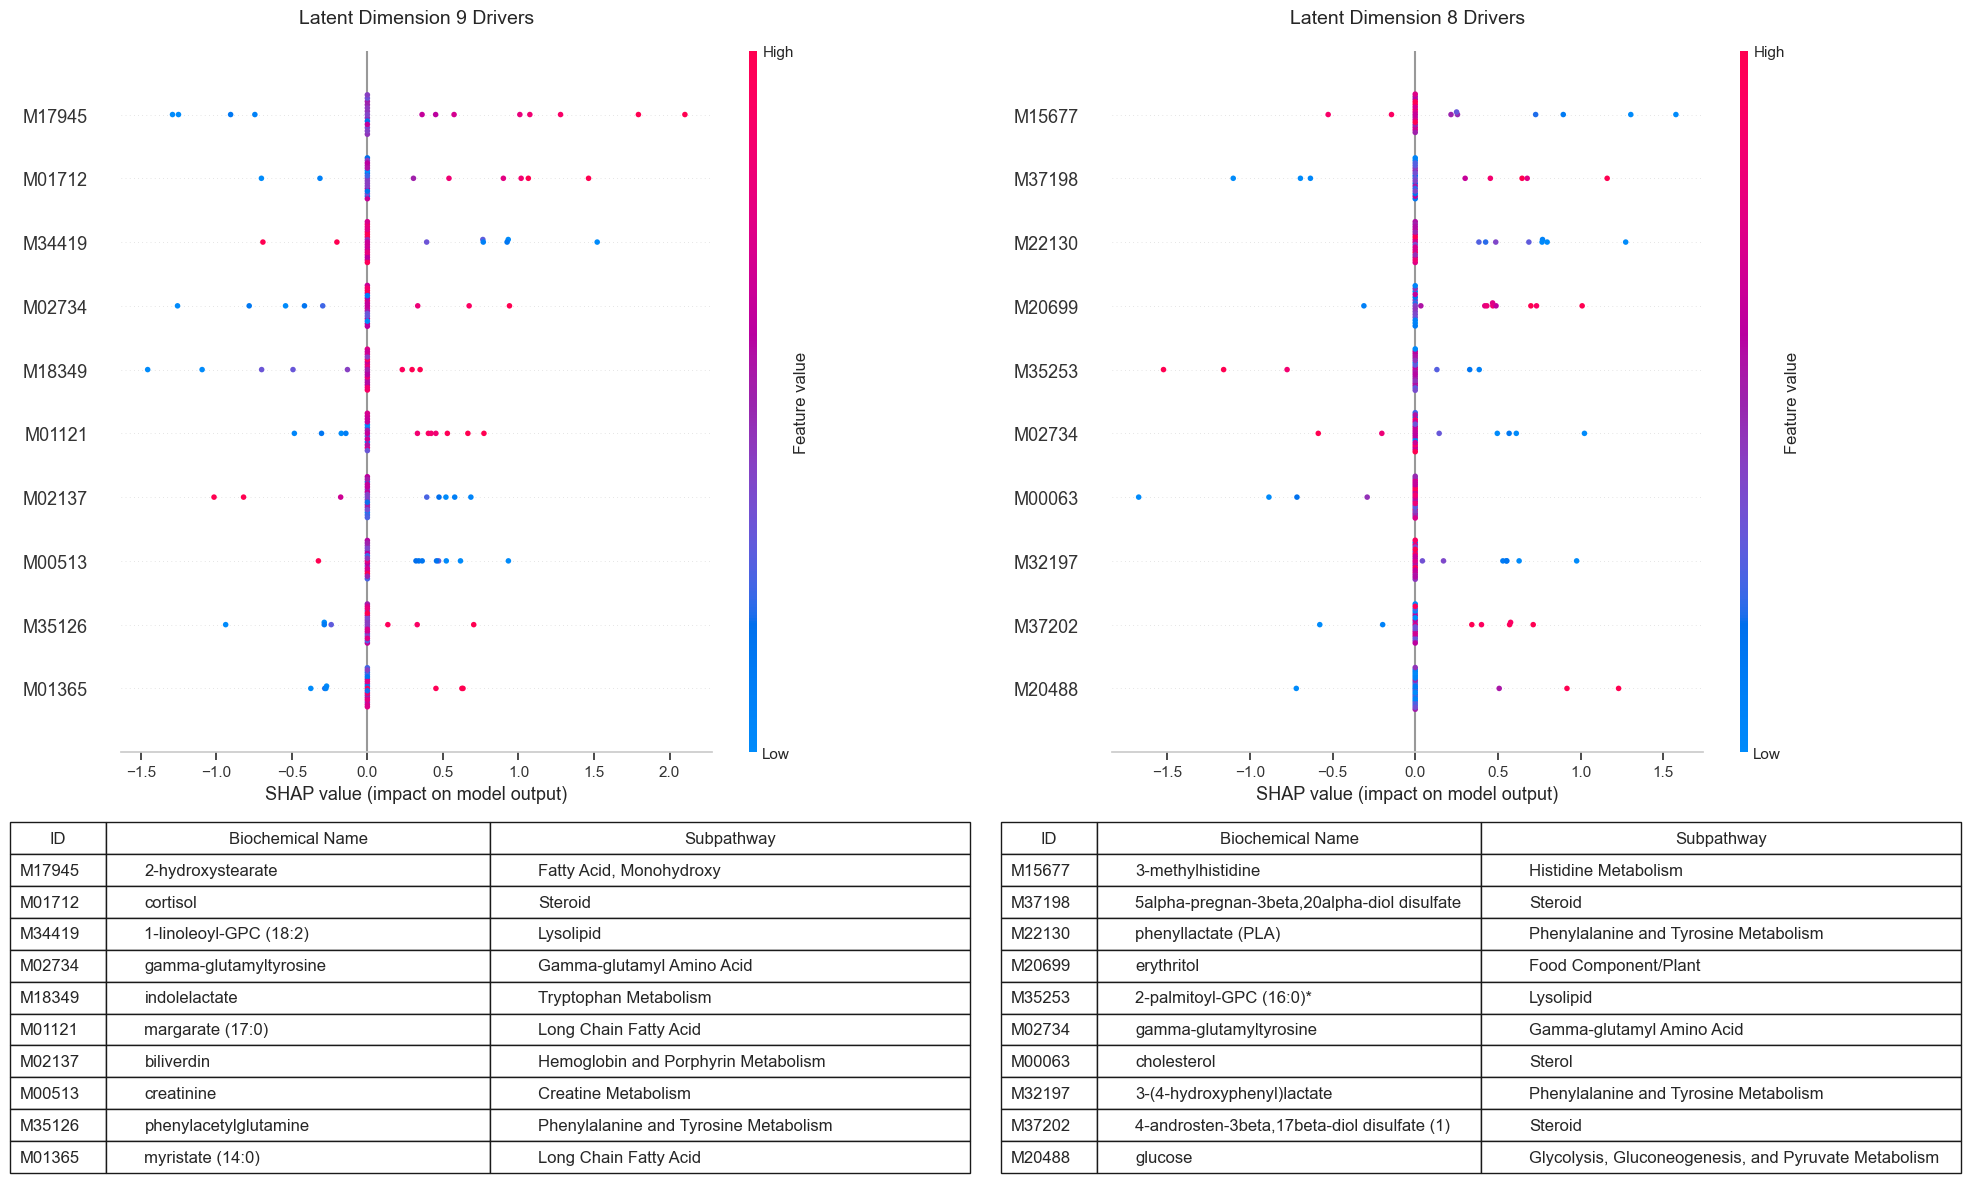

In [91]:
# 2 Latent Dimensions of interest (e.g. those with highest correlation to a given disease?)
dim_1 = 9
dim_2 = 8

# Transpose shap_values to make the rest of the function work
shap_values_T = np.transpose(shap_values, (2, 0, 1))

# Given a latent dimension number and a grid slot,
# creates a SHAP plot indicating "feature value" (relative levels of the metabolite) 
# and "SHAP value" (relevance of metabolite in latent dimension) for the top 10 metabolites.
# Also creates a table for this top 10 with the metabolite name and subpathway
def shap_with_table(latent_dim, gs_slot):
    # 1. Create a nested grid: Top for SHAP, Bottom for Table
    inner_grid = gs_slot.subgridspec(2, 1, height_ratios=[3, 1], hspace=0.4)
    ax_shap = fig.add_subplot(inner_grid[0])
    ax_table = fig.add_subplot(inner_grid[1])

    # 2. Plot the SHAP plot on top
    plt.sca(ax_shap)
    shap.summary_plot(
        shap_values_T[latent_dim], 
        test_subset, 
        feature_names=metabolite_ids,
        max_display=10,
        show=False,
        plot_size=None
    )
    plt.gca().grid(False)
    ax_shap.set_title(f"Latent Dimension {latent_dim} Drivers", fontsize=14, pad=20)

    # 3. Prepare the Metabolite Data for the table
    top_data = get_top_metabolites(shap_values_T[latent_dim], metabolite_ids)
    table_data = top_data[['BIOCHEMICAL', 'SUB_PATHWAY']].reset_index().values 

    # 4. Create the Table underneath
    ax_table.axis('off') # Hide the axes of the table slot
    tbl = ax_table.table(
        cellText=table_data,
        colLabels=['ID', 'Biochemical Name', 'Subpathway'],
        loc='center',
        cellLoc='left',
        bbox=[-0.15, 0, 1.3, 1.5] 
)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    
    col_widths = {0: 0.10, 1: 0.4, 2: 0.5}

    for (row, col), cell in tbl.get_celld().items():
        if col in col_widths:
            cell.set_width(col_widths[col])

# --- EXECUTION ---
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(1, 2) # 1 row, 2 columns of "slots"

shap_with_table(dim_1, gs[0])
shap_with_table(dim_2, gs[1])

plt.tight_layout()
plt.show()